<a href="https://colab.research.google.com/github/KeshavaOfficial/DataScience-Projects/blob/Projects/Power_Supply_Demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats

In [ ]:
# Load the dataset
df = pd.read_csv('PJMW_hourly.csv')

In [ ]:
# Step 1: Ensuring datetime format and consistency
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

In [ ]:
pip install ydata-profiling


In [ ]:
#Profilereport to get complete insights of the data
from ydata_profiling import ProfileReport
profile = ProfileReport(df, explorative = True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 2/2 [00:00<00:00,  2.69it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
print(df.columns)

Index(['Datetime', 'PJMW_MW'], dtype='object')


In [ ]:
# Step 1: Drop duplicate datetime entries
df = df.drop_duplicates(subset='Datetime', keep='first')

# Step 2: Set 'Datetime' column as the index
df.set_index('Datetime', inplace=True)

# Step 3: Set frequency to hourly (fill missing timestamps with NaNs)
df = df.asfreq('H')  # 'H' is the standard code for hourly frequency


<ipython-input-26-d40c92cfd9d5>:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')  # 'H' is the standard code for hourly frequency


In [ ]:
#Checking of null alues after setting index
null = df['PJMW_MW'].isnull().sum()
print(f"Nulls after indexing: {null}")

Nulls after indexing: 30


In [ ]:
# Forward fill
df['MW_ffill'] = df['PJMW_MW'].ffill()

In [ ]:
# Backward fill
df['MW_bfill'] = df['PJMW_MW'].bfill()

In [ ]:
# Linear Interpolation
df['MW_linear'] = df['PJMW_MW'].interpolate(method='linear')

In [31]:
# Spline interpolation for only missing values
if df['PJMW_MW'].isnull().any():
    df['MW_spline'] = df['PJMW_MW'].interpolate(method='spline', order=2)

In [32]:
# Time based interpolation
df['MW_time'] = df['PJMW_MW'].interpolate(method='time')

In [33]:
# Using the time-interpolated version for further analysis
df['MW_clean'] = df['MW_time']

In [34]:
## Step 3: Detect and treat outliers using z scores method
z_scores = np.abs(stats.zscore(df['MW_clean'].dropna()))
df['outlier'] = False
df.loc[df['MW_clean'].dropna().index[z_scores > 3], 'outlier'] = True

In [35]:
# Replace outliers with NaN and interpolate using the same metthod used preiously
df.loc[df['outlier'], 'MW_clean'] = np.nan
df['MW_clean'] = df['MW_clean'].interpolate(method='time')

In [36]:
# Step 4: Check for duplicates again
duplicates = df.index.duplicated().sum()
print(f"Duplicate after cleaning: {duplicates}")

Duplicate after cleaning: 0


In [37]:
# Step 5: ETS Decomposition (168 = 24 hours * 7 days for weekly pattern)
result = seasonal_decompose(df['MW_clean'], model='additive', period=168)

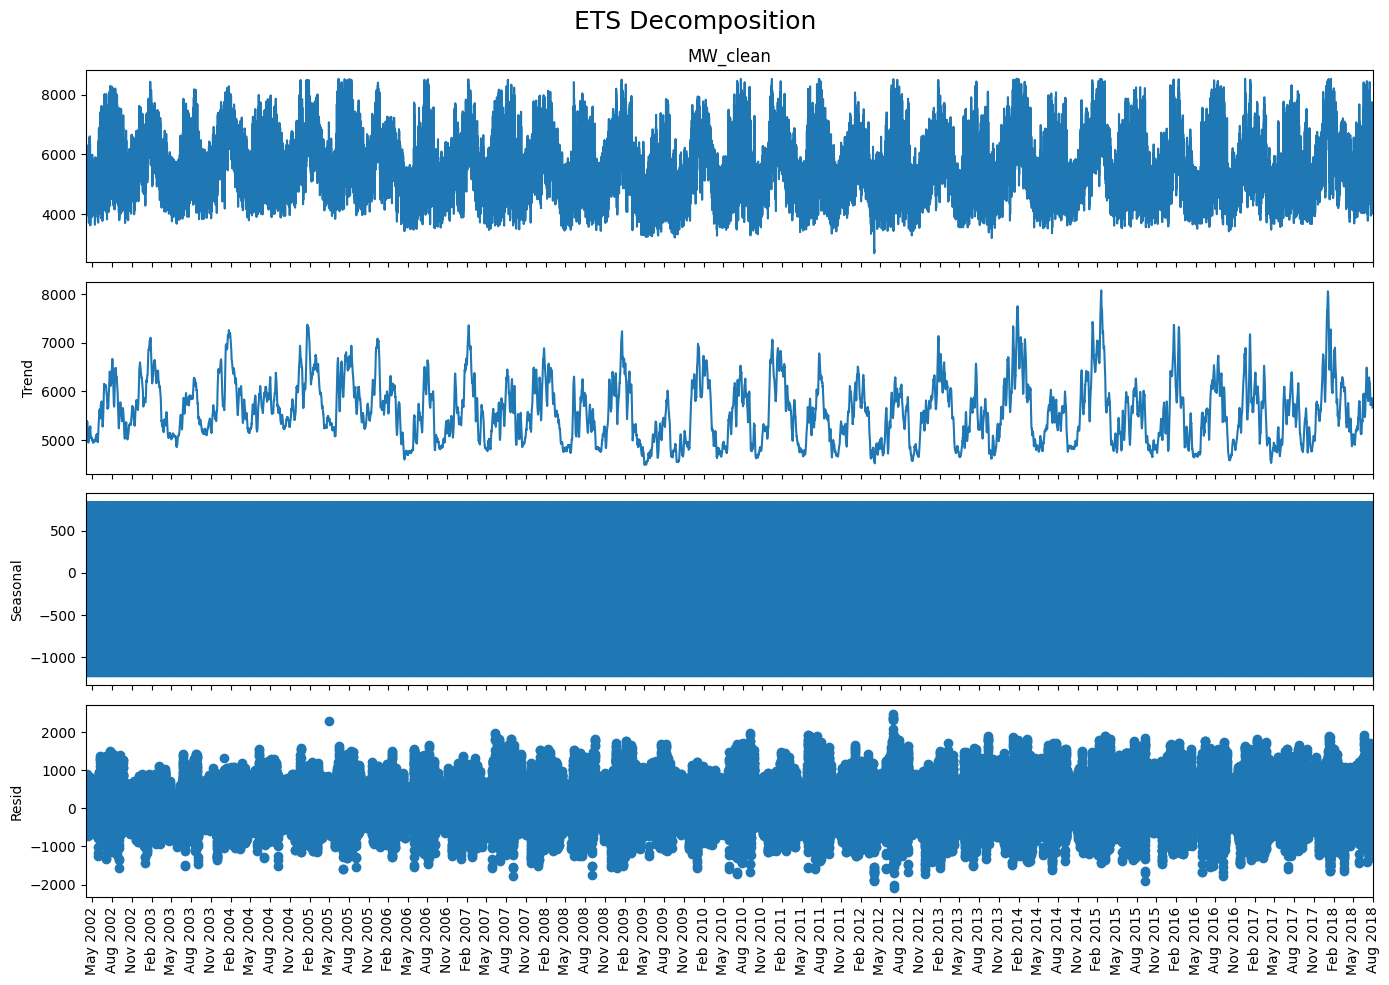

In [38]:
import matplotlib.dates as mdates

fig = result.plot()
fig.set_size_inches(14, 10)
fig.suptitle("ETS Decomposition", fontsize=18)

# Format x-axis for each subplot
for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Tick every 3 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Jan 2020'
    ax.tick_params(axis='x', rotation=90)  # Rotate for better readability

plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Make room for suptitle
plt.show()

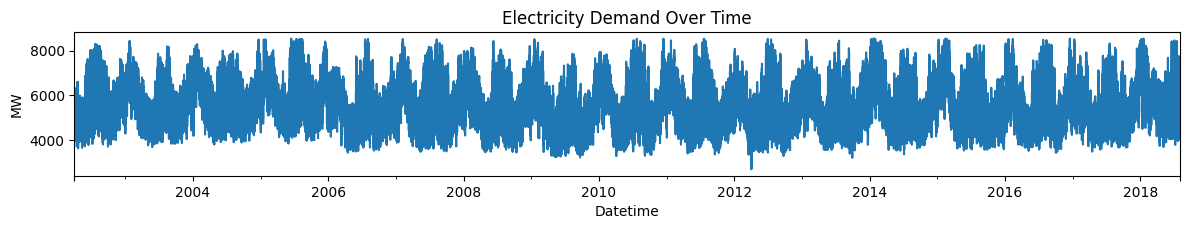

In [41]:
plt.figure(figsize=(12, 6))

# Time series line plot
plt.subplot(3, 1, 1)
df['MW_clean'].plot(color='tab:blue')  # Or use df['PJMW_MW'] if you want raw values
plt.title('Electricity Demand Over Time')
plt.ylabel('MW')
plt.xlabel('Datetime')

plt.tight_layout()
plt.show()



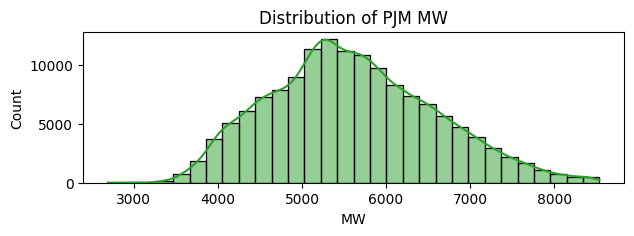

In [43]:
import seaborn as sns  # Add this if missing

# Optional: if df_final is not defined
# df_final = df.copy()

plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(3, 2, 3)
sns.histplot(df['MW_clean'], kde=True, bins=30, color='tab:green')
plt.title('Distribution of PJM MW')
plt.xlabel('MW')

plt.tight_layout()
plt.show()


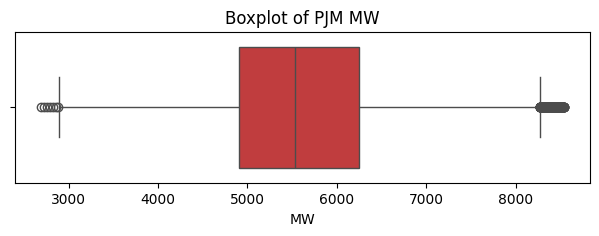

In [45]:
import seaborn as sns  # If not already imported

plt.figure(figsize=(12, 6))

# Boxplot of cleaned MW values
plt.subplot(3, 2, 4)
sns.boxplot(x=df['MW_clean'], color='tab:red')
plt.title('Boxplot of PJM MW')
plt.xlabel('MW')

plt.tight_layout()
plt.show()


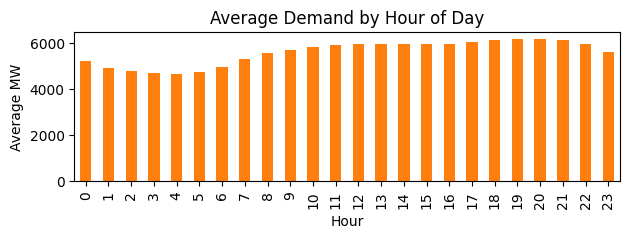

In [47]:
plt.figure(figsize=(12, 6))

# Hourly Average Demand
plt.subplot(3, 2, 5)
hourly_avg = df.groupby(df.index.hour)['MW_clean'].mean()
hourly_avg.plot(kind='bar', color='tab:orange')
plt.title('Average Demand by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average MW')

plt.tight_layout()
plt.show()




<ipython-input-49-577cfc44e67a>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=days, y=weekly_avg.values, palette='viridis')


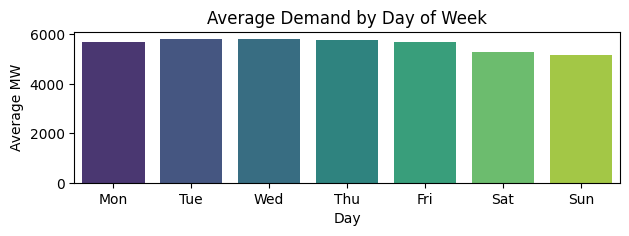

In [49]:
plt.figure(figsize=(12, 6))

# 5. Weekly Seasonality (Average MW by Day of Week)
plt.subplot(3, 2, 6)
weekly_avg = df.groupby(df.index.dayofweek)['MW_clean'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(x=days, y=weekly_avg.values, palette='viridis')
plt.title('Average Demand by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average MW')

plt.tight_layout()
plt.show()


#Line Plot with Rolling Trend (e.g. 7-day trend)

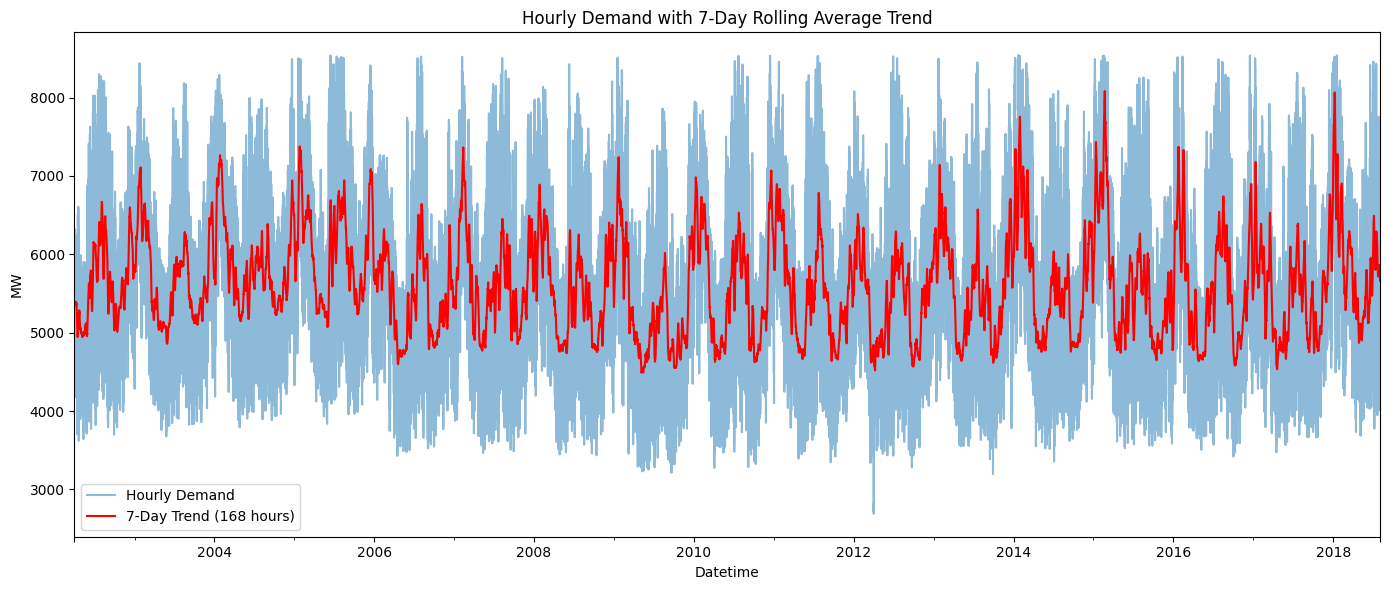

In [50]:
plt.figure(figsize=(14, 6))
df['MW_clean'].plot(label='Hourly Demand', alpha=0.5)
df['MW_clean'].rolling(window=168).mean().plot(label='7-Day Trend (168 hours)', color='red')  # 168 = 24*7
plt.title('Hourly Demand with 7-Day Rolling Average Trend')
plt.xlabel('Datetime')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()


#Heatmap: Hour of Day vs Day of Week

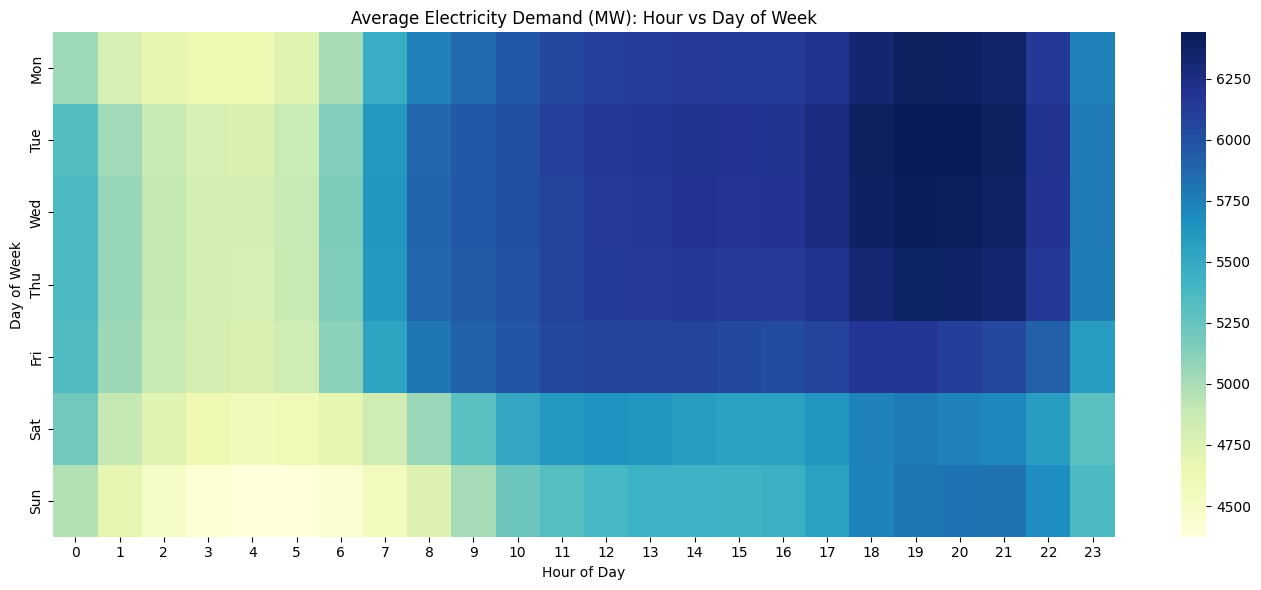

In [51]:
# Prepare pivot table for heatmap
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

# Compute average demand by (day, hour)
pivot = df.pivot_table(values='MW_clean', index='dayofweek', columns='hour', aggfunc='mean')

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', xticklabels=range(24), yticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('Average Electricity Demand (MW): Hour vs Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


#Monthly Seasonality Heatmap

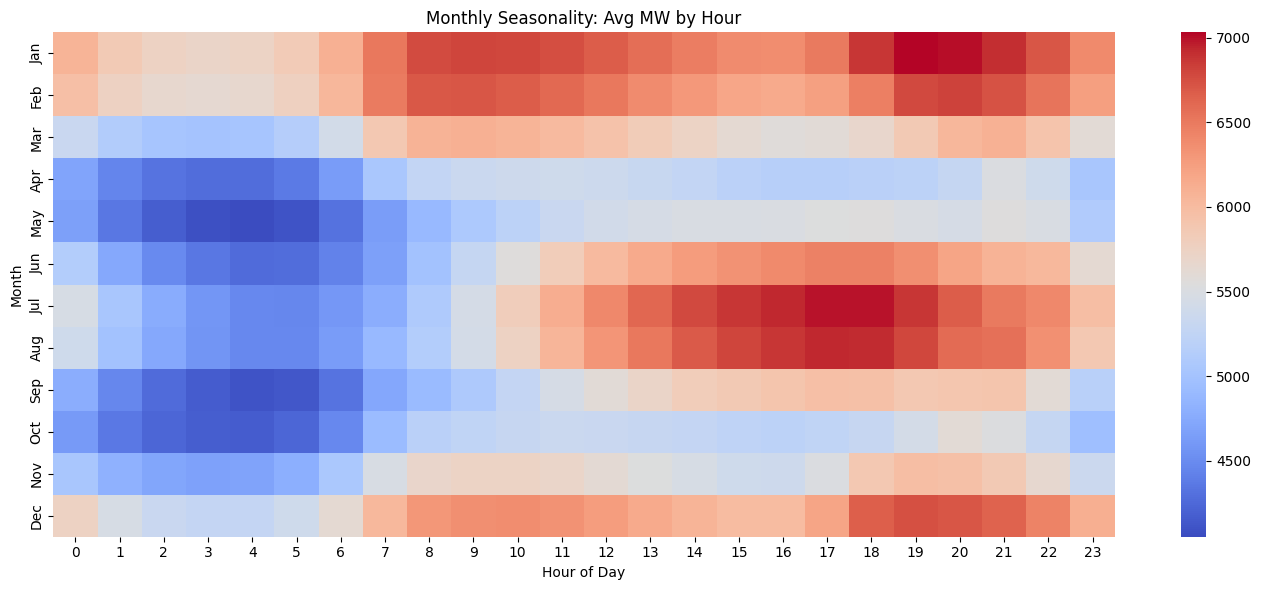

In [52]:
# Extract month and hour
df['month'] = df.index.month

# Create pivot table: rows = months, columns = hours
monthly_hourly = df.pivot_table(values='MW_clean', index='month', columns='hour', aggfunc='mean')

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(monthly_hourly, cmap='coolwarm', xticklabels=range(24), yticklabels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Seasonality: Avg MW by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Month')
plt.tight_layout()
plt.show()


#Clustering of Daily Demand Patterns

<ipython-input-53-42df992e5f71>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hourly_clean['cluster'] = clusters


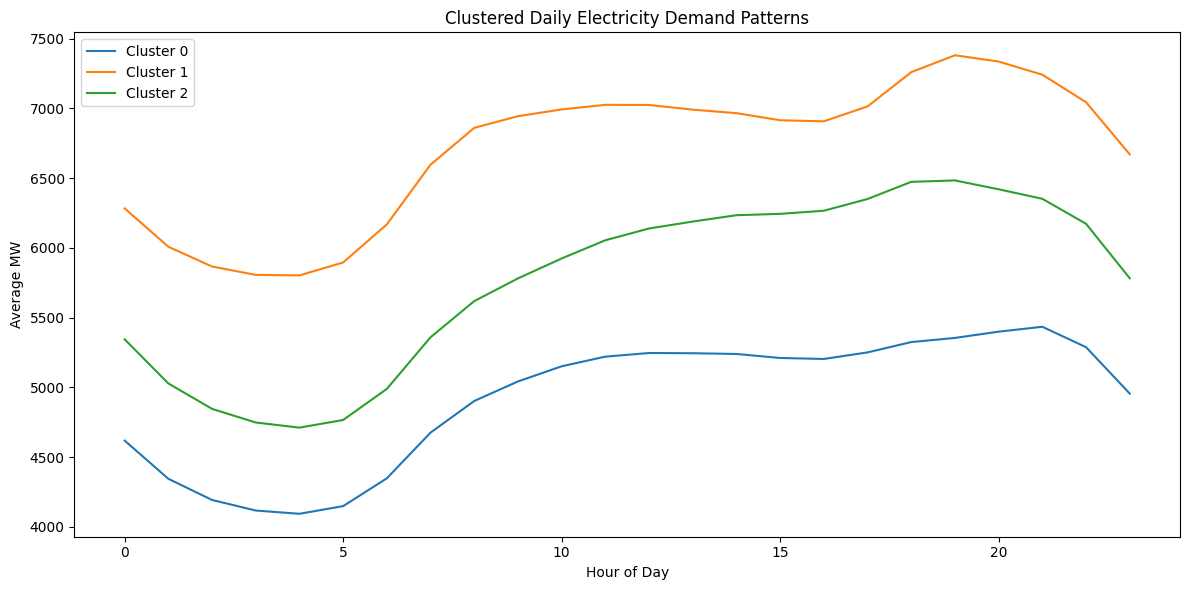

In [53]:
from sklearn.cluster import KMeans

# Resample to daily pattern
daily = df['MW_clean'].resample('D').mean()
daily_hourly = df['MW_clean'].groupby([df.index.date, df.index.hour]).mean().unstack()

# Drop rows with missing values
daily_hourly_clean = daily_hourly.dropna()

# KMeans clustering (e.g., 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(daily_hourly_clean)

# Assign clusters
daily_hourly_clean['cluster'] = clusters

# Plot cluster patterns
plt.figure(figsize=(12, 6))
for c in range(3):
    avg_pattern = daily_hourly_clean[daily_hourly_clean['cluster'] == c].drop('cluster', axis=1).mean()
    plt.plot(avg_pattern, label=f'Cluster {c}')

plt.title('Clustered Daily Electricity Demand Patterns')
plt.xlabel('Hour of Day')
plt.ylabel('Average MW')
plt.legend()
plt.tight_layout()
plt.show()
